# Safehouse Performance Monitoring Classifier

This notebook builds a **safehouse performance monitoring pipeline** for the INTEX IS 455 requirement. The goal is to help staff monitor safehouses over time and identify which **safehouse-months** may require added operational attention.

This notebook is intentionally structured to match the required assignment sections:

1. Problem Framing  
2. Data Acquisition, Preparation & Exploration  
3. Modeling & Feature Selection  
4. Evaluation & Interpretation  
5. Causal and Relationship Analysis  
6. Deployment Notes

The implementation is designed to stay consistent with the other pipeline notebooks:
- one complete setup cell
- robust relative-path handling for the nested CSV folder structure
- outputs written under `generated_outputs`
- reproducible feature engineering
- safer rerun behavior
- predictive modeling with a companion explanatory section

## 1. Problem Framing

### Business question
Which **safehouse-months** appear most likely to require additional management attention due to weaker-than-normal operational performance?

### Who cares about this?
This pipeline is most useful for:
- **admin and leadership staff** who need to monitor safehouses across locations
- **operations managers** who need to prioritize intervention and support
- **executive decision-makers** who need comparison across safehouses over time

### Why this matters
The organization operates with limited staff and multiple safehouses. Leadership needs a way to identify where performance may be drifting so they can intervene earlier instead of reacting late. A monthly safehouse monitoring model supports that need by converting many operational signals into a more usable attention flag.

### Predictive vs. explanatory choice
This notebook is **primarily predictive** because the model is intended for operational monitoring in the **Admin Dashboard** and **Reports & Analytics** pages. The notebook also includes a **relationship analysis** section so that the drivers of the safehouse-month risk signal can be interpreted carefully.

### Unit of analysis
The unit of analysis is a **safehouse-month** rather than a single safehouse overall. That gives a more useful monitoring cadence and provides a better structure for trend charts and comparisons across time.

### Target used in this notebook
The raw data does not contain a direct label called `safehouse_performance_flag`, so this notebook constructs one.

The target is:

- `safehouse_attention_flag = 1` if a safehouse-month falls into the weaker-performance group based on a composite of:
  - higher incident burden
  - weaker education progress
  - weaker health outcomes
  - lower reintegration momentum

- `safehouse_attention_flag = 0` otherwise

This is a practical monitoring proxy, not a perfect causal truth. That limitation is discussed later in the notebook.

In [53]:
# Imports, configuration, and helper functions

from pathlib import Path
import warnings
import os
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    # Import the scikit-learn tools used for preprocessing, modeling, tuning, and evaluation.
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.feature_selection import SelectFromModel
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_validate, RandomizedSearchCV
    from sklearn.metrics import (
        roc_auc_score,
        average_precision_score,
        f1_score,
        precision_score,
        recall_score,
        confusion_matrix,
        classification_report,
        RocCurveDisplay,
        PrecisionRecallDisplay
    )
    from sklearn.inspection import permutation_importance
except ImportError as exc:
    raise ImportError(
        "Missing required Python packages. Install them in the active Python environment with: "
        "python -m pip install scikit-learn pandas matplotlib"
    ) from exc

warnings.filterwarnings("ignore")

# Keep a fixed seed so results are more reproducible across reruns.
SEED = 27

# Use a fixed cutoff date so future-dated rows do not leak into training.
ANALYSIS_CUTOFF = pd.Timestamp("2026-04-06")

# Save notebook outputs under generated_outputs to match the project convention.
LOCAL_OUTPUT_DIR = Path("../generated_outputs")
OUTPUT_DIR = Path(os.environ.get("AZUREML_OUTPUT_DIR", str(LOCAL_OUTPUT_DIR)))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Check both the nested and non-nested CSV folder patterns used in this repo.
DATA_DIR_CANDIDATES = [
    Path("../data"),
    Path("./data"),
    Path("/mnt/batch/tasks/shared/LS_root/mounts/clusters/notebookdev/code/data"),
    Path("/lighthouse/lighthouse_csv_v7/lighthouse_csv_v7"),
    Path("/lighthouse/lighthouse_csv_v7"),
    Path("/lighthouse"),
    Path("./lighthouse_csv_v7/lighthouse_csv_v7"),
    Path("./lighthouse_csv_v7"),
    Path("../lighthouse_csv_v7/lighthouse_csv_v7"),
    Path("../lighthouse_csv_v7"),
]

def resolve_data_dir(candidates):
    # First, prefer a folder that directly contains CSV files.
    for candidate in candidates:
        if candidate.exists() and any(candidate.glob("*.csv")):
            return candidate

    # If the candidate exists but only contains a subfolder, drill down one level.
    for candidate in candidates:
        if candidate.exists():
            for sub in candidate.iterdir():
                if sub.is_dir() and any(sub.glob("*.csv")):
                    return sub

    raise FileNotFoundError(
        "Could not find a data folder containing CSV files. Checked: "
        + ", ".join(str(p.resolve()) for p in candidates)
    )

DATA_DIR = resolve_data_dir(DATA_DIR_CANDIDATES)

# List the files required specifically for the safehouse monitoring problem.
REQUIRED_FILES = {
    "safehouses": DATA_DIR / "safehouses.csv",
    "safehouse_monthly_metrics": DATA_DIR / "safehouse_monthly_metrics.csv",
    "residents": DATA_DIR / "residents.csv",
    "education_records": DATA_DIR / "education_records.csv",
    "health_wellbeing_records": DATA_DIR / "health_wellbeing_records.csv",
    "incident_reports": DATA_DIR / "incident_reports.csv",
    "intervention_plans": DATA_DIR / "intervention_plans.csv",
    "process_recordings": DATA_DIR / "process_recordings.csv",
}

print("Working directory:", Path.cwd())
print("Resolved data directory:", DATA_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())
print("CSV files found:")
for p in sorted(DATA_DIR.glob("*.csv")):
    print("-", p.name)

def assert_required_files_exist(required_files):
    # Stop early if any required file is missing.
    missing = [name for name, path in required_files.items() if not path.exists()]
    if missing:
        raise FileNotFoundError(
            f"Missing required CSV files: {missing}. Expected them under: {DATA_DIR.resolve()}"
        )

def load_csv_safe(path, parse_dates=None):
    # Fail clearly if the file path is wrong.
    if not Path(path).exists():
        raise FileNotFoundError(f"Could not find file: {path}")

    try:
        df = pd.read_csv(path)

        # Parse only the requested date columns that actually exist in the file.
        if parse_dates:
            for col in parse_dates:
                if col in df.columns:
                    df[col] = pd.to_datetime(df[col], errors="coerce")

        return df
    except Exception as exc:
        raise RuntimeError(f"Failed to load CSV at {path}: {exc}") from exc

def validate_required_columns(df, table_name, required_columns):
    # Compare the expected schema to the real file schema.
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise ValueError(f"Table '{table_name}' is missing required columns: {missing}")

def month_start(value):
    # Normalize dates to the first day of the month so tables merge cleanly.
    if pd.isna(value):
        return pd.NaT
    return pd.Timestamp(value).to_period("M").to_timestamp()

def filter_to_cutoff(df, date_cols, cutoff):
    # Drop records dated after the analysis cutoff to reduce leakage.
    df = df.copy()
    for col in date_cols:
        if col in df.columns:
            df = df[(df[col].isna()) | (df[col] <= cutoff)]
    return df

assert_required_files_exist(REQUIRED_FILES)

Working directory: c:\Users\Ashns\OneDrive\INTEX26\INTEX_W2026\ml-pipelines
Resolved data directory: C:\Users\Ashns\OneDrive\INTEX26\INTEX_W2026\ml-pipelines\lighthouse_csv_v7\lighthouse_csv_v7
Output directory: C:\Users\Ashns\OneDrive\INTEX26\INTEX_W2026\ml-pipelines\generated_outputs
CSV files found:
- donation_allocations.csv
- donations.csv
- education_records.csv
- health_wellbeing_records.csv
- home_visitations.csv
- in_kind_donation_items.csv
- incident_reports.csv
- intervention_plans.csv
- partner_assignments.csv
- partners.csv
- process_recordings.csv
- public_impact_snapshots.csv
- residents.csv
- safehouse_monthly_metrics.csv
- safehouses.csv
- social_media_posts.csv
- supporters.csv


## 2. Data Acquisition, Preparation & Exploration

This section loads the safehouse, resident, and case-management data needed to build a monthly safehouse monitoring dataset.

### Tables used
- `safehouses`
- `safehouse_monthly_metrics`
- `residents`
- `education_records`
- `health_wellbeing_records`
- `incident_reports`
- `intervention_plans`
- `process_recordings`

### Why these tables?
The monthly monitoring problem needs a safehouse-level view of:
- resident activity and count
- incidents and operational strain
- education and health progress
- case-management intensity
- intervention planning and reintegration movement

The available tables provide those signals directly or through aggregation.

In [54]:
# Load the source tables used in the safehouse pipeline.

safehouses = load_csv_safe(
    REQUIRED_FILES["safehouses"],
    parse_dates=["open_date"]
)

# This file stores the month as a start/end range rather than a single month column.
safehouse_monthly_metrics = load_csv_safe(
    REQUIRED_FILES["safehouse_monthly_metrics"],
    parse_dates=["month_start", "month_end"]
)

# Rename month_start once so the rest of the notebook can use metric_month consistently.
safehouse_monthly_metrics = safehouse_monthly_metrics.rename(
    columns={"month_start": "metric_month"}
)

residents = load_csv_safe(
    REQUIRED_FILES["residents"],
    parse_dates=["date_of_admission", "date_closed", "created_at"]
)

education_records = load_csv_safe(
    REQUIRED_FILES["education_records"],
    parse_dates=["record_date"]
)

health_records = load_csv_safe(
    REQUIRED_FILES["health_wellbeing_records"],
    parse_dates=["record_date"]
)

incident_reports = load_csv_safe(
    REQUIRED_FILES["incident_reports"],
    parse_dates=["incident_date", "resolution_date"]
)

intervention_plans = load_csv_safe(
    REQUIRED_FILES["intervention_plans"],
    parse_dates=["target_date", "case_conference_date", "created_at", "updated_at"]
)

process_recordings = load_csv_safe(
    REQUIRED_FILES["process_recordings"],
    parse_dates=["session_date"]
)

# Validate the key columns needed for joins and later feature engineering.
validate_required_columns(
    safehouses,
    "safehouses",
    ["safehouse_id", "name", "region"]
)

validate_required_columns(
    safehouse_monthly_metrics,
    "safehouse_monthly_metrics",
    ["safehouse_id", "metric_month"]
)

validate_required_columns(
    residents,
    "residents",
    ["resident_id", "safehouse_id", "date_of_admission"]
)

validate_required_columns(
    education_records,
    "education_records",
    ["resident_id", "record_date", "progress_percent", "attendance_rate"]
)

validate_required_columns(
    health_records,
    "health_wellbeing_records",
    ["resident_id", "record_date", "general_health_score"]
)

validate_required_columns(
    incident_reports,
    "incident_reports",
    ["resident_id", "incident_date", "severity"]
)

validate_required_columns(
    intervention_plans,
    "intervention_plans",
    ["resident_id", "status", "plan_category"]
)

validate_required_columns(
    process_recordings,
    "process_recordings",
    ["resident_id", "session_date", "session_duration_minutes", "session_type"]
)

print("safehouses:", safehouses.shape)
print("safehouse_monthly_metrics:", safehouse_monthly_metrics.shape)
print("residents:", residents.shape)
print("education_records:", education_records.shape)
print("health_records:", health_records.shape)
print("incident_reports:", incident_reports.shape)
print("intervention_plans:", intervention_plans.shape)
print("process_recordings:", process_recordings.shape)

safehouses: (9, 13)
safehouse_monthly_metrics: (450, 11)
residents: (60, 49)
education_records: (534, 10)
health_records: (534, 14)
incident_reports: (100, 12)
intervention_plans: (180, 11)
process_recordings: (2819, 15)


In [55]:
# Remove future-dated values so the training data stays historical.

safehouses = filter_to_cutoff(safehouses, ["open_date"], ANALYSIS_CUTOFF)
safehouse_monthly_metrics = filter_to_cutoff(safehouse_monthly_metrics, ["metric_month", "month_end"], ANALYSIS_CUTOFF)
residents = filter_to_cutoff(residents, ["date_of_admission", "date_closed", "created_at"], ANALYSIS_CUTOFF)
education_records = filter_to_cutoff(education_records, ["record_date"], ANALYSIS_CUTOFF)
health_records = filter_to_cutoff(health_records, ["record_date"], ANALYSIS_CUTOFF)
incident_reports = filter_to_cutoff(incident_reports, ["incident_date", "resolution_date"], ANALYSIS_CUTOFF)
intervention_plans = filter_to_cutoff(
    intervention_plans,
    ["target_date", "case_conference_date", "created_at", "updated_at"],
    ANALYSIS_CUTOFF
)
process_recordings = filter_to_cutoff(process_recordings, ["session_date"], ANALYSIS_CUTOFF)

# Print row counts after filtering so any unexpected drops are visible.
print("Rows after cutoff filtering")
print("safehouse_monthly_metrics:", safehouse_monthly_metrics.shape)
print("residents:", residents.shape)
print("education_records:", education_records.shape)
print("health_records:", health_records.shape)
print("incident_reports:", incident_reports.shape)
print("intervention_plans:", intervention_plans.shape)
print("process_recordings:", process_recordings.shape)

Rows after cutoff filtering
safehouse_monthly_metrics: (351, 11)
residents: (56, 49)
education_records: (534, 10)
health_records: (534, 14)
incident_reports: (99, 12)
intervention_plans: (180, 11)
process_recordings: (2763, 15)


In [56]:
# Build occupancy_rate if the file does not already provide it.

if "occupancy_rate" not in safehouses.columns:
    # Use current occupancy and capacity when both exist.
    if {"current_occupancy", "capacity_girls"}.issubset(safehouses.columns):
        safehouses["occupancy_rate"] = np.where(
            safehouses["capacity_girls"].fillna(0) > 0,
            safehouses["current_occupancy"] / safehouses["capacity_girls"],
            np.nan
        )
    else:
        # Fall back to missing if the raw ingredients are not available.
        safehouses["occupancy_rate"] = np.nan

safehouses[["safehouse_id", "name", "region", "occupancy_rate"]].head()

,safehouse_id,name,region,occupancy_rate
0,1,Lighthouse Safehouse 1,Luzon,1.000000
1,2,Lighthouse Safehouse 2,Visayas,0.800000
2,3,Lighthouse Safehouse 3,Mindanao,1.000000
3,4,Lighthouse Safehouse 4,Visayas,1.000000
4,5,Lighthouse Safehouse 5,Luzon,0.818182


In [57]:
# Add month fields to each table so they can be summarized to safehouse-month.
# Use the resident table as the main resident-to-safehouse lookup.
# Only merge safehouse_id into a table when that field is not already present.

residents["admission_month"] = residents["date_of_admission"].apply(month_start)
residents["close_month"] = residents["date_closed"].apply(month_start)
education_records["record_month"] = education_records["record_date"].apply(month_start)
health_records["record_month"] = health_records["record_date"].apply(month_start)
incident_reports["incident_month"] = incident_reports["incident_date"].apply(month_start)
intervention_plans["created_month"] = intervention_plans["created_at"].apply(month_start)
process_recordings["session_month"] = process_recordings["session_date"].apply(month_start)

resident_safehouse = residents[["resident_id", "safehouse_id", "date_of_admission", "date_closed"]].copy()

# Education records are resident-level, so attach the safehouse through the resident mapping.
education_safehouse = education_records.merge(
    resident_safehouse[["resident_id", "safehouse_id"]],
    on="resident_id",
    how="left"
)

# Health records use the same resident-to-safehouse logic.
health_safehouse = health_records.merge(
    resident_safehouse[["resident_id", "safehouse_id"]],
    on="resident_id",
    how="left"
)

# Incident reports may already store safehouse_id directly in some file versions.
incident_safehouse = incident_reports.copy()
if "safehouse_id" not in incident_safehouse.columns and "resident_id" in incident_safehouse.columns:
    incident_safehouse = incident_safehouse.merge(
        resident_safehouse[["resident_id", "safehouse_id"]],
        on="resident_id",
        how="left"
    )

# Intervention plans may also be either resident-based or already safehouse-based.
intervention_safehouse = intervention_plans.copy()
if "safehouse_id" not in intervention_safehouse.columns and "resident_id" in intervention_safehouse.columns:
    intervention_safehouse = intervention_safehouse.merge(
        resident_safehouse[["resident_id", "safehouse_id"]],
        on="resident_id",
        how="left"
    )

# Process recordings follow the same pattern.
process_safehouse = process_recordings.copy()
if "safehouse_id" not in process_safehouse.columns and "resident_id" in process_safehouse.columns:
    process_safehouse = process_safehouse.merge(
        resident_safehouse[["resident_id", "safehouse_id"]],
        on="resident_id",
        how="left"
    )

# Print missing-link rates so join issues show up early.
print("education_safehouse missing safehouse_id share:", round(education_safehouse["safehouse_id"].isna().mean(), 3))
print("health_safehouse missing safehouse_id share:", round(health_safehouse["safehouse_id"].isna().mean(), 3))
print("incident_safehouse missing safehouse_id share:", round(incident_safehouse["safehouse_id"].isna().mean(), 3))
print("intervention_safehouse missing safehouse_id share:", round(intervention_safehouse["safehouse_id"].isna().mean(), 3))
print("process_safehouse missing safehouse_id share:", round(process_safehouse["safehouse_id"].isna().mean(), 3))

education_safehouse missing safehouse_id share: 0.075
health_safehouse missing safehouse_id share: 0.075
incident_safehouse missing safehouse_id share: 0.0
intervention_safehouse missing safehouse_id share: 0.067
process_safehouse missing safehouse_id share: 0.042


In [58]:
# Build the monthly base table and aggregate each source table to safehouse-month.

base_monthly = safehouse_monthly_metrics.copy()
base_monthly["metric_month"] = base_monthly["metric_month"].apply(month_start)

# Count admissions by safehouse-month to capture inflow.
admissions_monthly = (
    residents.dropna(subset=["admission_month"])
    .groupby(["safehouse_id", "admission_month"])
    .agg(admissions_count=("resident_id", "count"))
    .reset_index()
    .rename(columns={"admission_month": "metric_month"})
)

# Count closures by safehouse-month to capture exits or reintegration movement.
closures_monthly = (
    residents.dropna(subset=["close_month"])
    .groupby(["safehouse_id", "close_month"])
    .agg(closures_count=("resident_id", "count"))
    .reset_index()
    .rename(columns={"close_month": "metric_month"})
)

# Summarize education progress at the safehouse-month level.
edu_monthly = (
    education_safehouse.dropna(subset=["record_month"])
    .groupby(["safehouse_id", "record_month"])
    .agg(
        avg_education_progress=("progress_percent", "mean"),
        avg_attendance_rate=("attendance_rate", "mean"),
        education_record_count=("resident_id", "count")
    )
    .reset_index()
    .rename(columns={"record_month": "metric_month"})
)

# Summarize health and wellbeing scores at the same monthly level.
health_monthly = (
    health_safehouse.dropna(subset=["record_month"])
    .groupby(["safehouse_id", "record_month"])
    .agg(
        avg_health_score=("general_health_score", "mean"),
        avg_sleep_quality_score=("sleep_quality_score", "mean"),
        avg_energy_level_score=("energy_level_score", "mean"),
        health_record_count=("resident_id", "count")
    )
    .reset_index()
    .rename(columns={"record_month": "metric_month"})
)

# Some versions of the incident file do not include follow_up_required.
if "follow_up_required" not in incident_safehouse.columns:
    incident_safehouse["follow_up_required"] = False

incident_count_field = "resident_id" if "resident_id" in incident_safehouse.columns else "incident_month"
plan_count_field = "resident_id" if "resident_id" in intervention_safehouse.columns else "created_month"
process_count_field = "resident_id" if "resident_id" in process_safehouse.columns else "session_month"

# Count incidents and break out severity-related features.
incident_monthly = (
    incident_safehouse.dropna(subset=["incident_month", "safehouse_id"])
    .groupby(["safehouse_id", "incident_month"])
    .agg(
        incident_count=(incident_count_field, "count"),
        high_severity_incidents=("severity", lambda s: (s == "High").sum()),
        medium_severity_incidents=("severity", lambda s: (s == "Medium").sum()),
        follow_up_incidents=("follow_up_required", lambda s: s.fillna(False).astype(bool).sum())
    )
    .reset_index()
    .rename(columns={"incident_month": "metric_month"})
)

# Summarize plan creation and reintegration-related activity.
plan_monthly = (
    intervention_safehouse.dropna(subset=["created_month", "safehouse_id"])
    .groupby(["safehouse_id", "created_month"])
    .agg(
        plans_created=(plan_count_field, "count"),
        achieved_plans=("status", lambda s: (s == "Achieved").sum()),
        reintegration_plans=("plan_category", lambda s: (s == "Reintegration").sum())
    )
    .reset_index()
    .rename(columns={"created_month": "metric_month"})
)

# Summarize counseling/process activity.
process_monthly = (
    process_safehouse.dropna(subset=["session_month", "safehouse_id"])
    .groupby(["safehouse_id", "session_month"])
    .agg(
        process_session_count=(process_count_field, "count"),
        avg_session_duration=("session_duration_minutes", "mean"),
        group_session_share=("session_type", lambda s: (s == "Group").mean())
    )
    .reset_index()
    .rename(columns={"session_month": "metric_month"})
)

# Build one safehouse-month skeleton from every monthly source.
monthly_index = pd.concat(
    [
        base_monthly[["safehouse_id", "metric_month"]],
        admissions_monthly[["safehouse_id", "metric_month"]],
        closures_monthly[["safehouse_id", "metric_month"]],
        edu_monthly[["safehouse_id", "metric_month"]],
        health_monthly[["safehouse_id", "metric_month"]],
        incident_monthly[["safehouse_id", "metric_month"]],
        plan_monthly[["safehouse_id", "metric_month"]],
        process_monthly[["safehouse_id", "metric_month"]],
    ],
    ignore_index=True
).drop_duplicates().sort_values(["safehouse_id", "metric_month"])

safehouse_month = monthly_index.copy()

# Merge each monthly feature set onto the skeleton.
for df_to_merge in [
    base_monthly,
    admissions_monthly,
    closures_monthly,
    edu_monthly,
    health_monthly,
    incident_monthly,
    plan_monthly,
    process_monthly
]:
    safehouse_month = safehouse_month.merge(
        df_to_merge,
        on=["safehouse_id", "metric_month"],
        how="left"
    )

# Add descriptive safehouse context for dashboards and grouping.
safehouse_month = safehouse_month.merge(
    safehouses[["safehouse_id", "name", "region", "occupancy_rate", "open_date"]],
    on="safehouse_id",
    how="left"
)

safehouse_month = safehouse_month.sort_values(["safehouse_id", "metric_month"]).reset_index(drop=True)
safehouse_month.head()

,safehouse_id,metric_month,metric_id,month_end,active_residents,avg_education_progress_x,avg_health_score_x,process_recording_count,home_visitation_count,incident_count_x,...,plans_created,achieved_plans,reintegration_plans,process_session_count,avg_session_duration,group_session_share,name,region,occupancy_rate,open_date
0,1.0,2023-01-01,1,2023-01-31,10,NaN,NaN,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,Lighthouse Safehouse 1,Luzon,1.0,2022-01-01
1,1.0,2023-02-01,2,2023-02-28,10,NaN,NaN,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,Lighthouse Safehouse 1,Luzon,1.0,2022-01-01
2,1.0,2023-03-01,3,2023-03-31,10,56.30,3.03,1,0,0,...,3.0,0.0,0.0,1.0,54.0,1.0,Lighthouse Safehouse 1,Luzon,1.0,2022-01-01
3,1.0,2023-04-01,4,2023-04-30,10,51.90,3.07,5,4,1,...,3.0,0.0,0.0,5.0,71.2,0.2,Lighthouse Safehouse 1,Luzon,1.0,2022-01-01
4,1.0,2023-05-01,5,2023-05-31,10,51.25,3.17,0,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,Lighthouse Safehouse 1,Luzon,1.0,2022-01-01


In [59]:
# Combine duplicate columns created by multiple merges.
safehouse_month["incident_count"] = (
    safehouse_month["incident_count_y"]
    .fillna(safehouse_month["incident_count_x"])
    .fillna(0)
)

safehouse_month["avg_education_progress"] = (
    safehouse_month["avg_education_progress_y"]
    .fillna(safehouse_month["avg_education_progress_x"])
)

safehouse_month["avg_health_score"] = (
    safehouse_month["avg_health_score_y"]
    .fillna(safehouse_month["avg_health_score_x"])
)

# Drop the duplicate suffixed columns after consolidating them.
safehouse_month = safehouse_month.drop(
    columns=[
        "incident_count_x", "incident_count_y",
        "avg_education_progress_x", "avg_education_progress_y",
        "avg_health_score_x", "avg_health_score_y"
    ],
    errors="ignore"
)

In [60]:
# Count active residents in each safehouse-month using admission and closure windows.

def active_residents_in_month(row, residents_df):
    safehouse_id = row["safehouse_id"]
    month_start_date = row["metric_month"]
    month_end_date = month_start_date + pd.offsets.MonthEnd(0)

    subset = residents_df[residents_df["safehouse_id"] == safehouse_id]
    active = subset[
        (subset["date_of_admission"].notna())
        & (subset["date_of_admission"] <= month_end_date)
        & (
            subset["date_closed"].isna()
            | (subset["date_closed"] >= month_start_date)
        )
    ]
    return active["resident_id"].nunique()

safehouse_month["active_residents"] = safehouse_month.apply(
    lambda row: active_residents_in_month(row, residents),
    axis=1
)

# Convert counts into rate-style features so safehouses of different sizes compare better.
safehouse_month["incidents_per_active_resident"] = np.where(
    safehouse_month["active_residents"].fillna(0) > 0,
    safehouse_month["incident_count"].fillna(0) / safehouse_month["active_residents"],
    0
)

safehouse_month["process_sessions_per_active_resident"] = np.where(
    safehouse_month["active_residents"].fillna(0) > 0,
    safehouse_month["process_session_count"].fillna(0) / safehouse_month["active_residents"],
    0
)

safehouse_month["closures_per_active_resident"] = np.where(
    safehouse_month["active_residents"].fillna(0) > 0,
    safehouse_month["closures_count"].fillna(0) / safehouse_month["active_residents"],
    0
)

# Keep simple calendar fields for reporting and model seasonality signals.
safehouse_month["month_num"] = safehouse_month["metric_month"].dt.month
safehouse_month["year_num"] = safehouse_month["metric_month"].dt.year

safehouse_month[[
    "safehouse_id", "metric_month", "active_residents",
    "incident_count", "incidents_per_active_resident",
    "avg_education_progress", "avg_health_score"
]].head()

,safehouse_id,metric_month,active_residents,incident_count,incidents_per_active_resident,avg_education_progress,avg_health_score
0,1.0,2023-01-01,0,0.0,0.0,NaN,NaN
1,1.0,2023-02-01,0,0.0,0.0,NaN,NaN
2,1.0,2023-03-01,1,0.0,0.0,56.30,3.03
3,1.0,2023-04-01,2,1.0,0.5,51.90,3.07
4,1.0,2023-05-01,2,0.0,0.0,51.25,3.17


In [61]:
# Add recent history features so the model can learn trend context instead of only the current month.

safehouse_month = safehouse_month.sort_values(["safehouse_id", "metric_month"]).copy()

lag_columns = [
    "active_residents",
    "incident_count",
    "incidents_per_active_resident",
    "avg_education_progress",
    "avg_health_score",
    "closures_count",
    "process_session_count",
    "process_sessions_per_active_resident"
]

for col in lag_columns:
    # lag1 captures the prior month.
    safehouse_month[f"{col}_lag1"] = safehouse_month.groupby("safehouse_id")[col].shift(1)

    # lag3_mean captures a short rolling history before the current month.
    safehouse_month[f"{col}_lag3_mean"] = (
        safehouse_month.groupby("safehouse_id")[col]
        .shift(1)
        .rolling(3, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )

# Measure how long each safehouse has been open by the given month.
safehouse_month["months_since_open"] = np.where(
    safehouse_month["open_date"].notna(),
    ((safehouse_month["metric_month"] - safehouse_month["open_date"]).dt.days / 30.4).clip(lower=0),
    np.nan
)

safehouse_month.head()

,safehouse_id,metric_month,metric_id,month_end,active_residents,process_recording_count,home_visitation_count,notes,admissions_count,closures_count,...,avg_education_progress_lag3_mean,avg_health_score_lag1,avg_health_score_lag3_mean,closures_count_lag1,closures_count_lag3_mean,process_session_count_lag1,process_session_count_lag3_mean,process_sessions_per_active_resident_lag1,process_sessions_per_active_resident_lag3_mean,months_since_open
0,1.0,2023-01-01,1,2023-01-31,0,0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.006579
1,1.0,2023-02-01,2,2023-02-28,0,0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.000000,13.026316
2,1.0,2023-03-01,3,2023-03-31,1,1,0,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.000000,13.947368
3,1.0,2023-04-01,4,2023-04-30,2,5,4,NaN,1.0,NaN,...,56.3,3.03,3.03,NaN,NaN,1.0,1.0,1.0,0.333333,14.967105
4,1.0,2023-05-01,5,2023-05-31,2,0,2,NaN,NaN,NaN,...,54.1,3.07,3.05,NaN,NaN,5.0,3.0,2.5,1.166667,15.953947


In [62]:
# Build the monitoring target from a composite attention score.

for col in [
    "incident_count", "incidents_per_active_resident", "high_severity_incidents",
    "avg_education_progress", "avg_health_score", "closures_per_active_resident"
]:
    if col not in safehouse_month.columns:
        safehouse_month[col] = np.nan

def zscore_safe(series):
    # Protect against divide-by-zero when a feature has no variance.
    series = series.copy()
    std = series.std(ddof=0)
    if pd.isna(std) or std == 0:
        return pd.Series(0, index=series.index)
    return (series - series.mean()) / std

safehouse_month["incident_z"] = zscore_safe(safehouse_month["incident_count"].fillna(0))
safehouse_month["incident_rate_z"] = zscore_safe(safehouse_month["incidents_per_active_resident"].fillna(0))

# Lower education and health should contribute to higher attention need.
safehouse_month["education_inverse_z"] = zscore_safe(
    safehouse_month["avg_education_progress"].fillna(safehouse_month["avg_education_progress"].median())
)
safehouse_month["health_inverse_z"] = zscore_safe(
    safehouse_month["avg_health_score"].fillna(safehouse_month["avg_health_score"].median())
)

# Lower closure / reintegration momentum also contributes to attention need.
safehouse_month["closure_inverse_z"] = zscore_safe(safehouse_month["closures_per_active_resident"].fillna(0))

safehouse_month["attention_score"] = (
    safehouse_month["incident_z"].fillna(0)
    + safehouse_month["incident_rate_z"].fillna(0)
    - safehouse_month["education_inverse_z"].fillna(0)
    - safehouse_month["health_inverse_z"].fillna(0)
    - safehouse_month["closure_inverse_z"].fillna(0)
)

# Flag the top quartile of attention scores as the positive class.
attention_threshold = safehouse_month["attention_score"].quantile(0.75)
safehouse_month["safehouse_attention_flag"] = (safehouse_month["attention_score"] >= attention_threshold).astype(int)

print("Safehouse-month rows:", len(safehouse_month))
print("Positive class threshold:", round(float(attention_threshold), 4))
print("Positive class rate:", round(safehouse_month["safehouse_attention_flag"].mean(), 3))

Safehouse-month rows: 351
Positive class threshold: 1.1588
Positive class rate: 0.251


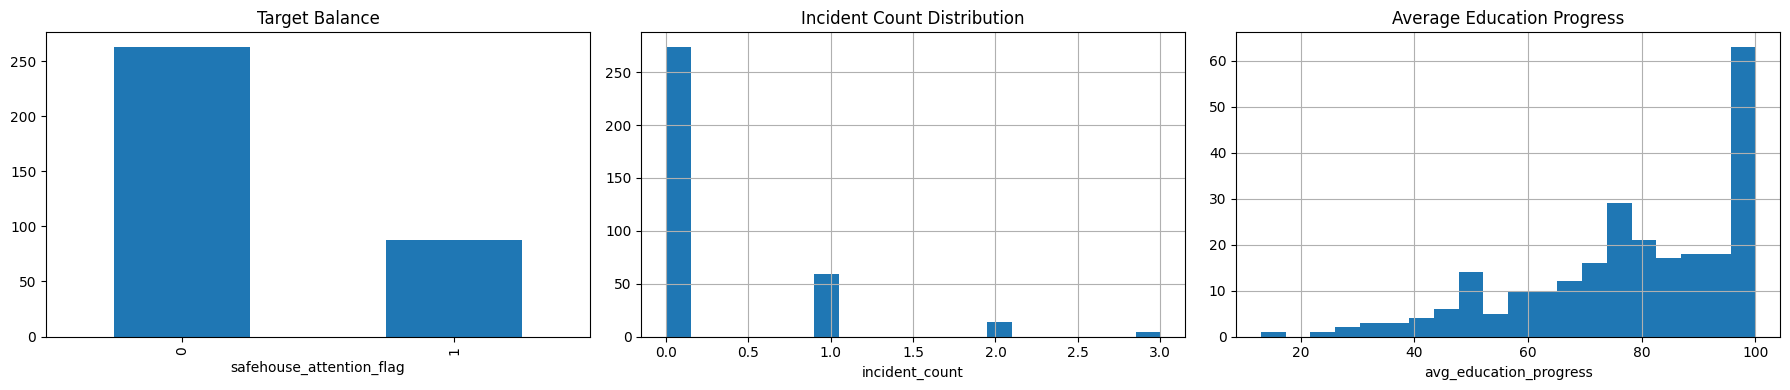

,feature,missing_fraction
0,notes,1.000000
1,closures_count,0.928775
2,closures_count_lag1,0.928775
3,admissions_count,0.854701
4,achieved_plans,0.854701
5,reintegration_plans,0.854701
6,plans_created,0.854701
7,closures_count_lag3_mean,0.803419
8,follow_up_incidents,0.780627
9,medium_severity_incidents,0.780627


In [63]:
# Plot the target and a few core monitoring features.

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

safehouse_month["safehouse_attention_flag"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Target Balance")
axes[0].set_xlabel("safehouse_attention_flag")

safehouse_month["incident_count"].fillna(0).hist(ax=axes[1], bins=20)
axes[1].set_title("Incident Count Distribution")
axes[1].set_xlabel("incident_count")

safehouse_month["avg_education_progress"].hist(ax=axes[2], bins=20)
axes[2].set_title("Average Education Progress")
axes[2].set_xlabel("avg_education_progress")

plt.tight_layout()
plt.show()

# Inspect missingness so weak columns are obvious before modeling.
missing_summary = (
    safehouse_month.isna().mean()
    .sort_values(ascending=False)
    .rename("missing_fraction")
    .reset_index()
    .rename(columns={"index": "feature"})
)
missing_summary.head(15)

### Feature engineering choices

This pipeline uses safehouse-month features that are useful for operational monitoring:
- resident volume and occupancy context
- incidents and incident rates
- education and health progress signals
- intervention planning counts
- process recording intensity
- lagged and rolling-history features
- regional and seasonal context

These are designed to support both monthly alerting and cross-safehouse comparison.

## 3. Modeling & Feature Selection

This section compares two predictive approaches:

1. **Feature-selected logistic regression**  
   - interpretable baseline
   - one-hot encoding for categorical features
   - model-based feature selection

2. **Random forest classifier**  
   - nonlinear candidate
   - useful when thresholds and interactions matter

### Validation strategy
Because the data contains multiple months from the same safehouse, this notebook uses **group-based splitting by safehouse**. That reduces leakage across time slices from the same location during evaluation.

In [64]:
# Prepare the modeling dataset and separate features from the target.

model_df = safehouse_month.copy()

drop_cols = [
    "safehouse_attention_flag",
    "attention_score",
    "incident_z",
    "incident_rate_z",
    "education_inverse_z",
    "health_inverse_z",
    "closure_inverse_z",
    "name",
    "metric_month",
    "open_date"
]

feature_df = model_df.drop(columns=[c for c in drop_cols if c in model_df.columns]).copy()
y = model_df["safehouse_attention_flag"].astype(int)
groups = model_df["safehouse_id"]

# Identify categorical vs numeric fields for the preprocessing pipeline.
categorical_features = [c for c in feature_df.columns if feature_df[c].dtype == "object" or str(feature_df[c].dtype) == "bool"]
numeric_features = [c for c in feature_df.columns if c not in categorical_features + ["safehouse_id"]]

X = feature_df.drop(columns=["safehouse_id"])

print("Model dataset shape:", X.shape)
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Unique safehouses:", groups.nunique())

Model dataset shape: (351, 49)
Numeric features: 48
Categorical features: 1
Unique safehouses: 9


In [72]:
# Split by safehouse group so the same safehouse does not appear in both train and test.

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

In [73]:
X_train = X_train.copy()
X_test = X_test.copy()

ref_month_end = X_train["month_end"].max()

X_train["month_end_year"] = X_train["month_end"].dt.year
X_train["month_end_month"] = X_train["month_end"].dt.month
X_train["month_end_quarter"] = X_train["month_end"].dt.quarter
X_train["month_end_days_from_ref"] = (ref_month_end - X_train["month_end"]).dt.days

X_test["month_end_year"] = X_test["month_end"].dt.year
X_test["month_end_month"] = X_test["month_end"].dt.month
X_test["month_end_quarter"] = X_test["month_end"].dt.quarter
X_test["month_end_days_from_ref"] = (ref_month_end - X_test["month_end"]).dt.days

X_train = X_train.drop(columns=["month_end"])
X_test = X_test.drop(columns=["month_end"])

In [74]:
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("numeric_features:", numeric_features)
print("categorical_features:", categorical_features)
print("month_end in X_train?", "month_end" in X_train.columns)
print("month_end in X_test?", "month_end" in X_test.columns)

numeric_features: ['metric_id', 'active_residents', 'process_recording_count', 'home_visitation_count', 'notes', 'admissions_count', 'closures_count', 'avg_attendance_rate', 'education_record_count', 'avg_sleep_quality_score', 'avg_energy_level_score', 'health_record_count', 'high_severity_incidents', 'medium_severity_incidents', 'follow_up_incidents', 'plans_created', 'achieved_plans', 'reintegration_plans', 'process_session_count', 'avg_session_duration', 'group_session_share', 'occupancy_rate', 'incident_count', 'avg_education_progress', 'avg_health_score', 'incidents_per_active_resident', 'process_sessions_per_active_resident', 'closures_per_active_resident', 'month_num', 'year_num', 'active_residents_lag1', 'active_residents_lag3_mean', 'incident_count_lag1', 'incident_count_lag3_mean', 'incidents_per_active_resident_lag1', 'incidents_per_active_resident_lag3_mean', 'avg_education_progress_lag1', 'avg_education_progress_lag3_mean', 'avg_health_score_lag1', 'avg_health_score_lag3_m

In [75]:
print("X_train:", len(X_train))
print("y_train:", len(y_train))
print("groups_train:", len(groups_train))

X_train: 234
y_train: 234
groups_train: 234


In [76]:
# Build preprocessing and candidate model pipelines.

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features)
    ]
)

# Use L1-regularized logistic regression to shrink weak features before the final logistic model.
logit_feature_selector = SelectFromModel(
    estimator=LogisticRegression(
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        max_iter=2000,
        random_state=SEED
    ),
    threshold="median"
)

logit_pipeline = Pipeline(steps=[
    ("prep", preprocessor),
    ("feature_select", logit_feature_selector),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=SEED
    ))
])

# Use random forest as the nonlinear comparison model.
rf_pipeline = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1
    ))
])

cv = GroupKFold(n_splits=min(4, groups_train.nunique()))
scoring = {
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall"
}

# Cross-validate both candidates on the grouped training data.
logit_cv = cross_validate(
    logit_pipeline,
    X_train,
    y_train,
    groups=groups_train,
    cv=cv,
    scoring=scoring,
    n_jobs=None
)

rf_cv = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    groups=groups_train,
    cv=cv,
    scoring=scoring,
    n_jobs=None
)

cv_results = pd.DataFrame({
    "model": ["LogisticRegression+FeatureSelection", "RandomForest"],
    "cv_roc_auc_mean": [logit_cv["test_roc_auc"].mean(), rf_cv["test_roc_auc"].mean()],
    "cv_avg_precision_mean": [logit_cv["test_avg_precision"].mean(), rf_cv["test_avg_precision"].mean()],
    "cv_f1_mean": [logit_cv["test_f1"].mean(), rf_cv["test_f1"].mean()],
    "cv_precision_mean": [logit_cv["test_precision"].mean(), rf_cv["test_precision"].mean()],
    "cv_recall_mean": [logit_cv["test_recall"].mean(), rf_cv["test_recall"].mean()],
})

cv_results.sort_values("cv_roc_auc_mean", ascending=False)

,model,cv_roc_auc_mean,cv_avg_precision_mean,cv_f1_mean,cv_precision_mean,cv_recall_mean
0,LogisticRegression+FeatureSelection,0.977763,0.929935,0.822040,0.859580,0.815980
1,RandomForest,0.953453,0.847554,0.695185,0.703365,0.688828


In [77]:
# Tune the random forest lightly so the notebook stays practical to rerun.

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions={
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [None, 4, 6, 8],
        "model__min_samples_leaf": [1, 2, 4, 6],
        "model__max_features": ["sqrt", "log2", None]
    },
    n_iter=10,
    scoring="roc_auc",
    cv=cv,
    random_state=SEED,
    n_jobs=-1,
    verbose=0
)

rf_search.fit(X_train, y_train, groups=groups_train)

best_rf_pipeline = rf_search.best_estimator_
print("Best RF params:", rf_search.best_params_)
print("Best RF CV ROC AUC:", round(rf_search.best_score_, 4))

Best RF params: {'model__n_estimators': 300, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 8}
Best RF CV ROC AUC: 0.9623


## 4. Evaluation & Interpretation

This section evaluates the selected predictive model on a holdout set containing different safehouses than the training folds.

### Error costs in this context
- **False positive**: The model flags a safehouse-month as needing attention when it does not.  
  This may cause leadership to spend time reviewing a location that is performing acceptably.

- **False negative**: The model fails to flag a safehouse-month that really needs attention.  
  This is usually more costly, because it may delay operational support or corrective action.

Because this is a monitoring pipeline, recall is especially important. Missing a truly struggling safehouse-month is usually worse than reviewing one extra month that turns out to be fine.

In [78]:
# Fit the candidate models on the training split and evaluate on the holdout safehouses.

logit_pipeline.fit(X_train, y_train)
best_rf_pipeline.fit(X_train, y_train)

def evaluate_classifier(model, X_eval, y_eval, model_name):
    # Predict probabilities first so threshold-based and ranking metrics can both be used.
    y_proba = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_proba >= 0.50).astype(int)

    metrics = {
        "model": model_name,
        "roc_auc": roc_auc_score(y_eval, y_proba),
        "avg_precision": average_precision_score(y_eval, y_proba),
        "f1": f1_score(y_eval, y_pred, zero_division=0),
        "precision": precision_score(y_eval, y_pred, zero_division=0),
        "recall": recall_score(y_eval, y_pred, zero_division=0),
    }

    return metrics, y_proba, y_pred

logit_metrics, logit_proba, logit_pred = evaluate_classifier(logit_pipeline, X_test, y_test, "LogisticRegression+FeatureSelection")
rf_metrics, rf_proba, rf_pred = evaluate_classifier(best_rf_pipeline, X_test, y_test, "RandomForestTuned")

test_results = pd.DataFrame([logit_metrics, rf_metrics]).sort_values("roc_auc", ascending=False)
test_results

,model,roc_auc,avg_precision,f1,precision,recall
0,LogisticRegression+FeatureSelection,0.993623,0.985951,0.966667,1.000000,0.935484
1,RandomForestTuned,0.983871,0.952170,0.814815,0.956522,0.709677


In [79]:
# Choose the stronger holdout model for deployment-style scoring.

if rf_metrics["roc_auc"] >= logit_metrics["roc_auc"]:
    final_model = best_rf_pipeline
    final_model_name = "RandomForestTuned"
    final_proba = rf_proba
    final_pred = rf_pred
else:
    final_model = logit_pipeline
    final_model_name = "LogisticRegression+FeatureSelection"
    final_proba = logit_proba
    final_pred = logit_pred

print("Selected final predictive model:", final_model_name)
print(classification_report(y_test, final_pred, zero_division=0))

# Show the confusion matrix in table form for easier interpretation.
cm = confusion_matrix(y_test, final_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)
cm_df

Selected final predictive model: LogisticRegression+FeatureSelection
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        86
           1       1.00      0.94      0.97        31

    accuracy                           0.98       117
   macro avg       0.99      0.97      0.98       117
weighted avg       0.98      0.98      0.98       117



,Predicted 0,Predicted 1
Actual 0,86,0
Actual 1,2,29


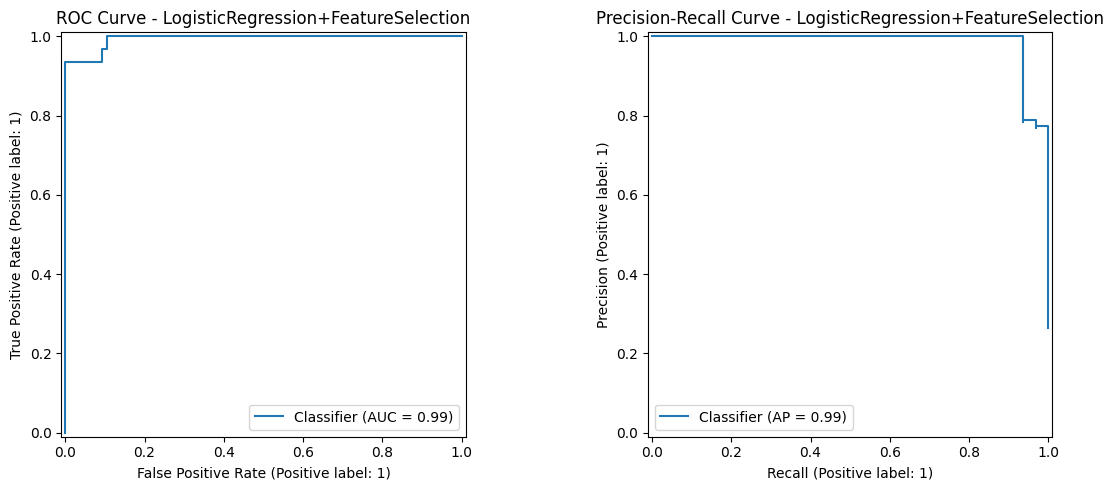

In [80]:
# Plot ROC and precision-recall curves for the chosen model.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, final_proba, ax=axes[0])
axes[0].set_title(f"ROC Curve - {final_model_name}")

PrecisionRecallDisplay.from_predictions(y_test, final_proba, ax=axes[1])
axes[1].set_title(f"Precision-Recall Curve - {final_model_name}")

plt.tight_layout()
plt.show()

### Business interpretation

If this model performs reasonably well, it should be used as a **monitoring and prioritization tool**, not as a replacement for judgment.

Useful interpretations:
- safehouse-months with the highest scores should be reviewed first by staff or leadership
- low-scoring safehouse-months are not “guaranteed healthy,” but they appear lower-priority relative to others
- the model can support executive comparison across locations by showing where attention signals are most concentrated over time

# Measure feature importance with permutation importance on the holdout set.

perm = permutation_importance(
    final_model,
    X_test,
    y_test,
    n_repeats=15,
    random_state=SEED,
    scoring="roc_auc"
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

importance_df.head(15)

In [81]:
# Fit a smaller companion model for association-style interpretation.

explanatory_features = [c for c in X.columns if c in [
    "region",
    "occupancy_rate",
    "active_residents",
    "incident_count_lag1",
    "incidents_per_active_resident_lag1",
    "avg_education_progress_lag1",
    "avg_health_score_lag1",
    "closures_count_lag1",
    "process_session_count_lag1",
    "plans_created",
    "achieved_plans",
    "reintegration_plans",
    "month_num",
    "year_num",
]]

cat_explain = [c for c in explanatory_features if X_train[c].dtype == "object" or str(X_train[c].dtype) == "bool"]
num_explain = [c for c in explanatory_features if c not in cat_explain]

explain_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_explain),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_explain)
    ]
)

explain_model = Pipeline(steps=[
    ("prep", explain_preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=SEED
    ))
])

explain_model.fit(X_train[explanatory_features], y_train)

# Pull the transformed feature names and coefficients together for interpretation.
feature_names = explain_model.named_steps["prep"].get_feature_names_out()
coef_values = explain_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coef_values,
    "abs_coefficient": abs(coef_values)
}).sort_values("abs_coefficient", ascending=False)

coef_df.head(15)

,feature,coefficient,abs_coefficient
1,num__plans_created,0.675453,0.675453
9,num__avg_education_progress_lag1,-0.471307,0.471307
10,num__avg_health_score_lag1,-0.414316,0.414316
11,num__closures_count_lag1,-0.304233,0.304233
12,num__process_session_count_lag1,0.261750,0.261750
13,cat__region_Luzon,0.224371,0.224371
14,cat__region_Mindanao,-0.217104,0.217104
6,num__year_num,0.163904,0.163904
2,num__achieved_plans,0.152274,0.152274
0,num__active_residents,0.136737,0.136737


In [82]:
# Companion explanatory model

explanatory_features = [c for c in X.columns if c in [
    "region",
    "occupancy_rate",
    "active_residents",
    "incident_count_lag1",
    "incidents_per_active_resident_lag1",
    "avg_education_progress_lag1",
    "avg_health_score_lag1",
    "closures_count_lag1",
    "process_session_count_lag1",
    "plans_created",
    "achieved_plans",
    "reintegration_plans",
    "month_num",
    "year_num",
]]

cat_explain = [c for c in explanatory_features if X_train[c].dtype == "object" or str(X_train[c].dtype) == "bool"]
num_explain = [c for c in explanatory_features if c not in cat_explain]

explain_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_explain),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_explain)
    ]
)

explain_model = Pipeline(steps=[
    ("prep", explain_preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=SEED
    ))
])

explain_model.fit(X_train[explanatory_features], y_train)

feature_names = explain_model.named_steps["prep"].get_feature_names_out()
coef_values = explain_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coef_values,
    "abs_coefficient": abs(coef_values)
}).sort_values("abs_coefficient", ascending=False)

coef_df.head(15)

,feature,coefficient,abs_coefficient
1,num__plans_created,0.675453,0.675453
9,num__avg_education_progress_lag1,-0.471307,0.471307
10,num__avg_health_score_lag1,-0.414316,0.414316
11,num__closures_count_lag1,-0.304233,0.304233
12,num__process_session_count_lag1,0.261750,0.261750
13,cat__region_Luzon,0.224371,0.224371
14,cat__region_Mindanao,-0.217104,0.217104
6,num__year_num,0.163904,0.163904
2,num__achieved_plans,0.152274,0.152274
0,num__active_residents,0.136737,0.136737


### Relationship analysis write-up

When you review the feature importance and coefficient outputs above, look for patterns such as:
- whether rising incidents are associated with higher attention risk
- whether stronger education and health outcomes are associated with lower attention risk
- whether reintegration-related movement is associated with stronger safehouse performance
- whether high occupancy and resident load are associated with operational strain

Important caution:
- these patterns are **not automatically causal**
- a feature may be predictive because it reflects staff response rather than root cause
- for example, more plans created or more process sessions may indicate high need rather than high success
- regional patterns may capture differences in population, referral environment, or reporting behavior rather than inherent safehouse quality

In the final report, be explicit:
- **what the model predicts**
- **what the model suggests**
- **what the model does not prove**

# Score the latest available month so the output can feed the website.

latest_month = safehouse_month["metric_month"].max()
latest_safehouse_view = safehouse_month[safehouse_month["metric_month"] == latest_month].copy()

# Reuse the trained final model on the feature columns used during training.
latest_features = latest_safehouse_view[X.columns].copy()
latest_safehouse_view["safehouse_attention_probability"] = final_model.predict_proba(latest_features)[:, 1]
latest_safehouse_view["predicted_safehouse_attention_flag"] = (
    latest_safehouse_view["safehouse_attention_probability"] >= 0.50
).astype(int)

# Stamp the output so the app knows when the score file was generated.
latest_safehouse_view["prediction_timestamp"] = pd.Timestamp.now()
latest_safehouse_view["model_name"] = final_model_name

monitoring_output = latest_safehouse_view.sort_values("safehouse_attention_probability", ascending=False).copy()

output_path = OUTPUT_DIR / "safehouse_performance_scores.csv"
monitoring_output.to_csv(output_path, index=False)

print(f"Saved live scoring output to: {output_path.resolve()}")
monitoring_output[[
    "safehouse_id",
    "name",
    "region",
    "metric_month",
    "safehouse_attention_probability",
    "predicted_safehouse_attention_flag",
    "active_residents",
    "incident_count",
    "avg_education_progress",
    "avg_health_score"
]].head(15)

In [85]:
# Build a live safehouse monitoring output for the latest available month

def add_month_end_features(df, ref_month_end):
    df = df.copy()
    df["month_end_year"] = df["month_end"].dt.year
    df["month_end_month"] = df["month_end"].dt.month
    df["month_end_quarter"] = df["month_end"].dt.quarter
    df["month_end_days_from_ref"] = (ref_month_end - df["month_end"]).dt.days
    df = df.drop(columns=["month_end"])
    return df

if "safehouse_month" not in globals():
    raise NameError("safehouse_month is not defined. Run the earlier aggregation cells first.")
if "final_model" not in globals():
    raise NameError("final_model is not defined. Run the model selection cell first.")
if "X_train" not in globals():
    raise NameError("X_train is not defined. Run the model preparation cell first.")
if "final_model_name" not in globals():
    raise NameError("final_model_name is not defined. Run the model selection cell first.")

latest_month = safehouse_month["metric_month"].max()
ref_month_end = pd.Timestamp(latest_month).to_period("M").end_time

latest_safehouse_view = safehouse_month[safehouse_month["metric_month"] == latest_month].copy()
latest_safehouse_view = add_month_end_features(latest_safehouse_view, ref_month_end)

missing_columns = [col for col in X_train.columns if col not in latest_safehouse_view.columns]
if missing_columns:
    raise KeyError(
        f"latest_safehouse_view is missing required model columns: {missing_columns}"
    )

latest_features = latest_safehouse_view[X_train.columns].copy()
latest_safehouse_view["safehouse_attention_probability"] = final_model.predict_proba(latest_features)[:, 1]
latest_safehouse_view["predicted_safehouse_attention_flag"] = (
    latest_safehouse_view["safehouse_attention_probability"] >= 0.50
).astype(int)
latest_safehouse_view["prediction_timestamp"] = pd.Timestamp.now()
latest_safehouse_view["model_name"] = final_model_name

monitoring_output = latest_safehouse_view.sort_values("safehouse_attention_probability", ascending=False).copy()

output_path = OUTPUT_DIR / "safehouse_performance_scores.csv"
monitoring_output.to_csv(output_path, index=False)

print(f"Saved live scoring output to: {output_path.resolve()}")
monitoring_output[[
    "safehouse_id",
    "name",
    "region",
    "metric_month",
    "safehouse_attention_probability",
    "predicted_safehouse_attention_flag",
    "active_residents",
    "incident_count",
    "avg_education_progress",
    "avg_health_score"
]].head(15)

Saved live scoring output to: C:\Users\Ashns\OneDrive\INTEX26\INTEX_W2026\ml-pipelines\generated_outputs\safehouse_performance_scores.csv


,safehouse_id,name,region,metric_month,safehouse_attention_probability,predicted_safehouse_attention_flag,active_residents,incident_count,avg_education_progress,avg_health_score
155,4.0,Lighthouse Safehouse 4,Visayas,2026-03-01,0.025830,0,5,0.0,NaN,NaN
272,7.0,Lighthouse Safehouse 7,Visayas,2026-03-01,0.023122,0,4,0.0,NaN,NaN
233,6.0,Lighthouse Safehouse 6,Mindanao,2026-03-01,0.018344,0,4,0.0,NaN,NaN
350,9.0,Lighthouse Safehouse 9,Mindanao,2026-03-01,0.016291,0,1,0.0,NaN,NaN
116,3.0,Lighthouse Safehouse 3,Mindanao,2026-03-01,0.012109,0,2,0.0,NaN,NaN
77,2.0,Lighthouse Safehouse 2,Visayas,2026-03-01,0.005470,0,3,0.0,NaN,NaN
194,5.0,Lighthouse Safehouse 5,Luzon,2026-03-01,0.004111,0,4,0.0,NaN,NaN
311,8.0,Lighthouse Safehouse 8,Visayas,2026-03-01,0.003449,0,1,0.0,NaN,NaN
38,1.0,Lighthouse Safehouse 1,Luzon,2026-03-01,0.002668,0,6,0.0,NaN,NaN


## Final Notes

This notebook is designed to be:
- executable top to bottom
- explicit about the prediction vs. explanation distinction
- aligned with the textbook emphasis on preparation, classification, evaluation, feature selection, and deployment
- useful for both operational monitoring and executive comparison across safehouses

Before final submission, update any wording to match your team’s actual UI, repo paths, and deployment implementation.

In [ ]:
# Mirror outputs back to the local repo fallback after writing to Azure ML output storage when available.
import shutil
LOCAL_OUTPUT_DIR = Path("../generated_outputs")
if OUTPUT_DIR.resolve() != LOCAL_OUTPUT_DIR.resolve():
    LOCAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    for artifact in OUTPUT_DIR.glob('*'):
        if artifact.is_file():
            shutil.copy2(artifact, LOCAL_OUTPUT_DIR / artifact.name)
    print(f'Mirrored outputs to local fallback: {LOCAL_OUTPUT_DIR.resolve()}')
